# Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

## Background

This notebook documents the modeling workflow used for the EDS 232 final project Kaggle competition. The goal is to predict dissolved inorganic carbon (`DIC`, in ?mol/kg) for seawater samples collected by the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program.

The response variable is `DIC`. The predictor variables are:

- `CTDTEMP_ITS90`: sea water temperature in degrees C
- `Salinity_PSS78`: practical salinity
- `Depth`: sample depth below the surface in meters
- `TA`: total alkalinity in µmol/kg

The notebook includes setup, exploratory data analysis, model tuning, model comparison, and creation of a Kaggle submission file. The final selected model is a tuned random forest regression model because it performed best on the validation split.

## Setup

Load libraries, read the training and test data, and define the response and predictor columns. The code below first checks for files in `data/`, then falls back to the current folder. This makes the notebook easier to run whether the CSVs are stored as `data/train.csv` and `data/test.csv` or as `train.csv` and `test.csv`.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Set random state to 42 for subsequent model application
RANDOM_STATE = 42


In [ ]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

predictors = ["CTDTEMP_ITS90", "Salinity_PSS78", "Depth", "TA"]
response = "DIC"

X = df_train[predictors]
y = df_train[response]
X_kaggle_test = df_test[predictors]

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)
df_train.head()

Training data shape: (3389, 6)
Test data shape: (848, 5)


,id,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
0,0,15.36,33.6095,10.0,2241.0,1989.4
1,1,11.23,33.6095,10.0,2241.0,1989.8
2,2,11.23,33.6095,10.0,2241.0,1989.3
3,3,11.23,33.6095,10.0,2241.0,1988.6
4,4,15.06,33.2820,10.0,2241.0,1991.5


## Exploratory Data Analysis

This section checks the structure of the data, missing values, distributions of the predictors and response, and relationships between predictors and `DIC`. These summaries help decide whether nonlinear models may be useful and whether any preprocessing is needed.

In [44]:
# Basic data checks
print("Training columns:")
print(df_train.columns.tolist())

print("\nMissing values in training data:")
print(df_train[predictors + [response]].isna().sum())

print("\nMissing values in test data:")
print(df_test[predictors].isna().sum())

print("\nSummary statistics:")
df_train[predictors + [response]].describe()

Training columns:
['id', 'CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA', 'DIC']

Missing values in training data:
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
DIC               0
dtype: int64

Missing values in test data:
CTDTEMP_ITS90     0
Salinity_PSS78    0
Depth             0
TA                0
dtype: int64

Summary statistics:


,CTDTEMP_ITS90,Salinity_PSS78,Depth,TA,DIC
count,3389.000000,3389.000000,3389.000000,3389.000000,3389.000000
mean,11.819258,33.701898,144.232546,2251.047300,2117.764680
std,3.905980,0.375517,262.640488,32.675546,116.876574
min,1.520000,32.700000,0.000000,2163.800000,1934.100000
25%,8.749000,33.415000,10.000000,2229.400000,2008.700000
50%,11.230000,33.609500,50.000000,2241.000000,2083.300000
75%,14.916000,34.068000,230.000000,2267.100000,2225.600000
max,22.750000,34.680000,3542.000000,2462.300000,2364.600000


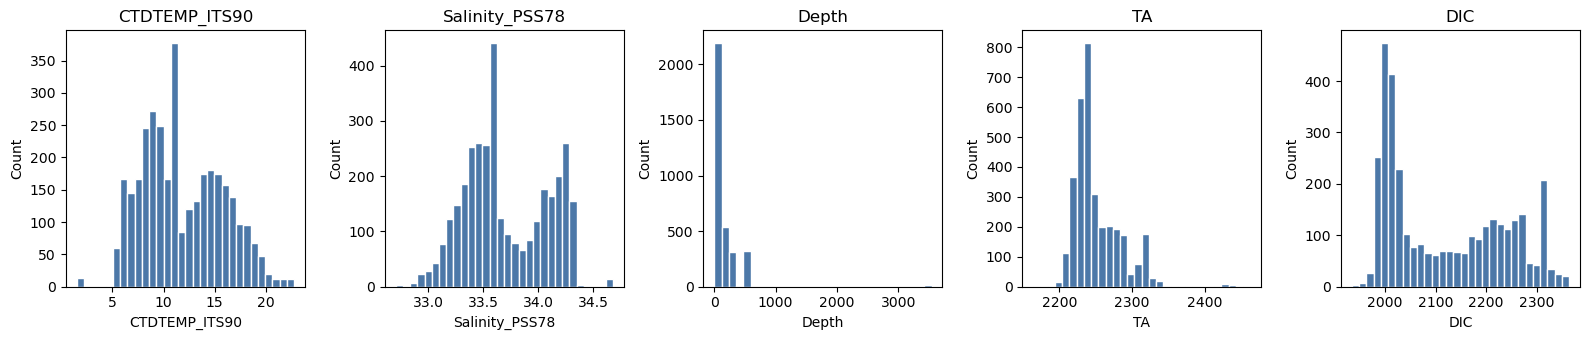

In [45]:
# Distributions of predictors and response
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
cols_to_plot = predictors + [response]

for i in range(len(cols_to_plot)):
    col = cols_to_plot[i]
    ax = axes[i]

    ax.hist(df_train[col], bins=30, color="#4C78A8", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

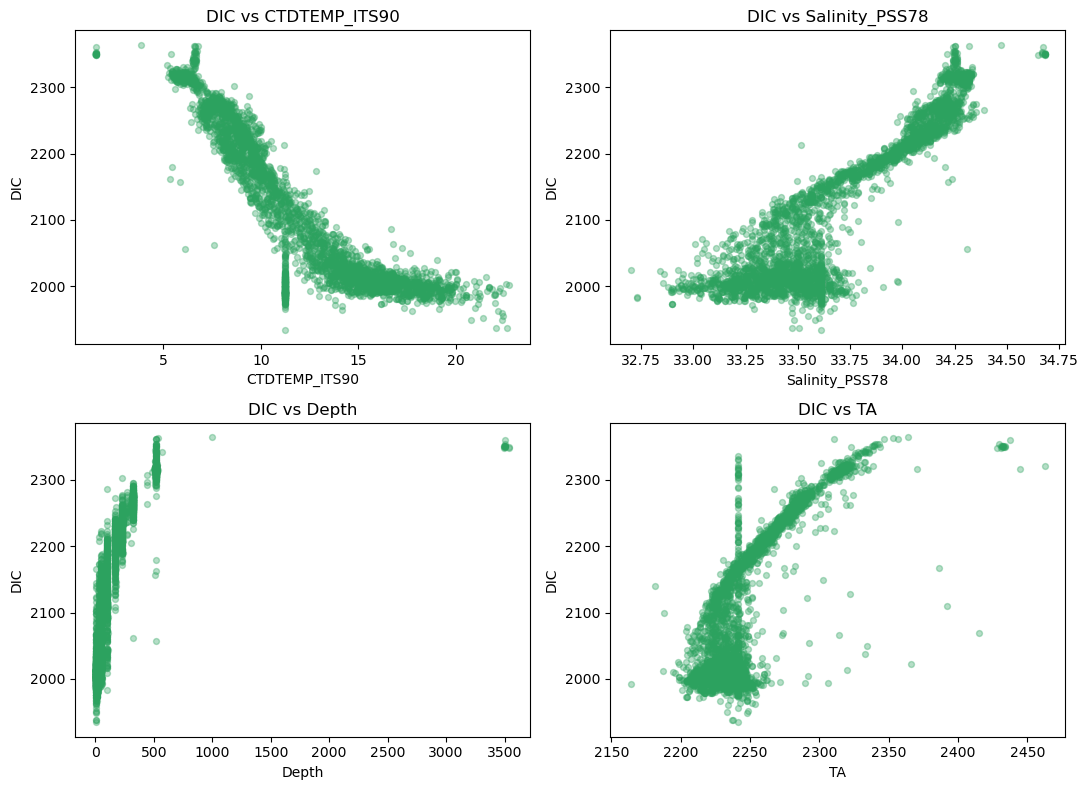

In [46]:
# Relationships between each predictor and DIC
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for i in range(len(predictors)):
    col = predictors[i]
    ax = axes[i]

    ax.scatter(df_train[col], df_train[response], alpha=0.35, s=18, color="#2CA25F")
    ax.set_xlabel(col)
    ax.set_ylabel("DIC")
    ax.set_title(f"DIC vs {col}")

plt.tight_layout()
plt.show()

                CTDTEMP_ITS90  Salinity_PSS78     Depth        TA       DIC
CTDTEMP_ITS90        1.000000       -0.778143 -0.606716 -0.673803 -0.880959
Salinity_PSS78      -0.778143        1.000000  0.624730  0.855702  0.898543
Depth               -0.606716        0.624730  1.000000  0.762256  0.643485
TA                  -0.673803        0.855702  0.762256  1.000000  0.803202
DIC                 -0.880959        0.898543  0.643485  0.803202  1.000000


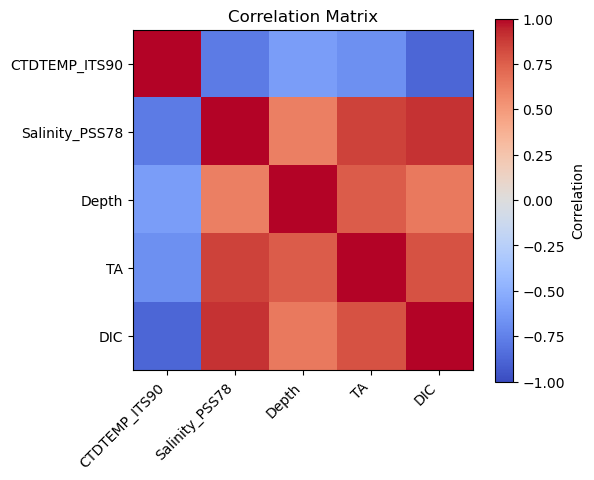

In [47]:
# Correlation matrix for a quick view of linear relationships
corr = df_train[predictors + [response]].corr(numeric_only=True)
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Models

The Kaggle competition evaluates predictions using mean squared error (MSE). In this notebook, models are compared using validation MSE, RMSE, and R². RMSE is included because it is in the same units as `DIC`, which makes interpretation easier.

The workflow consists of the following steps:

1. Split the training data into training and validation sets.
2. Fit a multiple linear regression baseline.
3. Tune a ridge regression model using a hyperparameter grid over `alpha`.
4. Tune a random forest regression model using a hyperparameter grid.
5. Compare validation performance and select the best model.
6. Refit the selected model on all training data and predict the Kaggle test data.

In [48]:
# Helper function to evaluate models on the validation set.
def evaluate_model(model_name, model, X, y):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    return {
        "model": model_name,
        "Train mse": mse,
        "Train rmse": rmse,
        "Train r2": r2
    }

model_results = []

### Model 1: Multiple Linear Regression Baseline

Multiple linear regression is used as a simple baseline. It has no major hyperparameters to tune, so no grid search is needed. This model assumes a linear relationship between the predictors and `DIC`.

In [52]:
# Fit a multiple linear regression baseline
lm = LinearRegression()
lm.fit(X, y)

lm_results = evaluate_model("Multiple Linear Regression",
                            lm,
                            X,
                            y)

model_results.append(lm_results)

print("Multiple Linear Regression Performance")
print(f"Validation MSE:  {lm_results['Train mse']:.4f}")
print(f"Validation RMSE: {lm_results['Train rmse']:.4f}")
print(f"Validation R²:   {lm_results['Train r2']:.4f}")

pd.Series(lm.coef_, index=predictors).sort_values(ascending=False)

Multiple Linear Regression Performance
Validation MSE:  1438.7851
Validation RMSE: 37.9313
Validation R²:   0.8946


Salinity_PSS78    138.324490
TA                  0.403663
Depth               0.000900
CTDTEMP_ITS90     -13.700393
dtype: float64

In [ ]:
# To see 
print(lm_results.keys())

dict_keys(['model', 'Train mse', 'Train rmse', 'Train r2'])


### Model 2: Ridge Regression with Hyperparameter Tuning

Ridge regression is a regularized linear model. It keeps the model linear, but adds an L2 penalty that can reduce overfitting when predictors are correlated. The main hyperparameter is `alpha`: larger values apply stronger regularization and shrink coefficients more strongly.

Because ridge regression is sensitive to the scale of the predictors, the model is fit inside a pipeline with `StandardScaler`.

In [ ]:
# Store features in an array to extract
'''features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]
features 

# Extract from train and store as X and y
X_train =  train[features]
y_train = train["DIC"]

# Extract from test and store as X_test
X_test = test[features]'''

In [ ]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)  # fit on train only
X_test_scaled   = scaler.transform(X_kaggle_test)  # reuse train stats


In [ ]:
# Now we need to tune alpha with grid search (CV gives comparison MSE)
param_grid = {"alpha": np.logspace(-3, 3, 50)}
ridge_search = GridSearchCV(
    Ridge(), param_grid, scoring="neg_mean_squared_error", cv=5
)
ridge_search.fit(X_train_scaled, y)

best_alpha = ridge_search.best_params_["alpha"]
print("Best alpha:", best_alpha)
print("Best CV MSE:", -ridge_search.best_score_)  # Ridge comparison number

Best alpha: 25.595479226995334
Best CV MSE: 1601.6905703329028


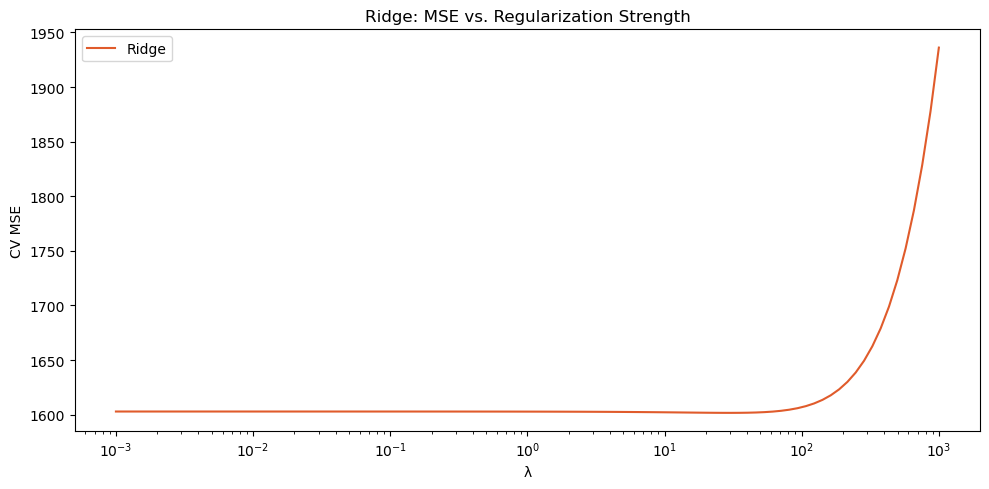

In [65]:
# Visualize the CV MSE for each alpha (taken from lab)
mse_ridge = []
lambdas = np.logspace(-3, 3, 100)
for lam in lambdas:
    scores = cross_val_score(
        Ridge(alpha=lam), X_train_scaled, y,
        scoring="neg_mean_squared_error", cv=5
    )
    mse_ridge.append(-scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_ridge, label='Ridge', color='#E05B2B')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('CV MSE')
plt.title('Ridge: MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

### Model 3: Random Forest Regression with Hyperparameter Tuning

Random forest regression is a tree-based ensemble method. It builds many decision trees using bootstrapped samples of the training data, then averages their predictions. This makes the model useful for nonlinear relationships and interactions among predictors.

The tuned hyperparameters are:

- `n_estimators`: number of trees in the forest. More trees can improve stability, but increase runtime.
- `max_depth`: maximum depth of each tree. Smaller values reduce complexity and can reduce overfitting.
- `min_samples_split`: minimum number of samples required to split an internal node. Larger values make trees less complex.
- `min_samples_leaf`: minimum number of samples required in a terminal leaf. Larger values smooth predictions.
- `max_features`: number of predictors considered at each split. Lower values increase diversity across trees.

Random forests do not require feature scaling because they split variables using thresholds.

In [66]:
# Baseline random forest before tuning
rf_baseline = RandomForestRegressor(random_state=RANDOM_STATE)
rf_baseline.fit(X, y)

rf_baseline_results = evaluate_model("Random Forest Baseline", rf_baseline, X, y)
model_results.append(rf_baseline_results)

print("Baseline Random Forest Performance")
print(f"Validation MSE:  {rf_baseline_results['validation_mse']:.4f}")
print(f"Validation RMSE: {rf_baseline_results['validation_rmse']:.4f}")
print(f"Validation R²:   {rf_baseline_results['validation_r2']:.4f}")

Baseline Random Forest Performance


KeyError: 'validation_mse'

In [ ]:
# Create parameter grid for parameters to tune
rf_param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 1.0],
} # validation RMSE

# Create parameter grid for RF regression model
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Fit the RF regression model
rf_grid.fit(X, y)

# Extract the best parameters for the model and evaluate
best_rf = rf_grid.best_estimator_
rf_tuned_results = evaluate_model("Random Forest Tuned", best_rf, X, y)
model_results.append(rf_tuned_results)y

print("Tuned Random Forest Performance")
print("Best parameters:", rf_grid.best_params_)
print(f"Validation MSE:  {rf_tuned_results['validation_mse']:.4f}")
print(f"Validation RMSE: {rf_tuned_results['validation_rmse']:.4f}")
print(f"Validation R²:   {rf_tuned_results['validation_r2']:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Tuned Random Forest Performance
Best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}
Validation MSE:  151.7313
Validation RMSE: 12.3179
Validation R²:   0.9890


CTDTEMP_ITS90     0.502726
Salinity_PSS78    0.302265
Depth             0.158373
TA                0.036636
dtype: float64


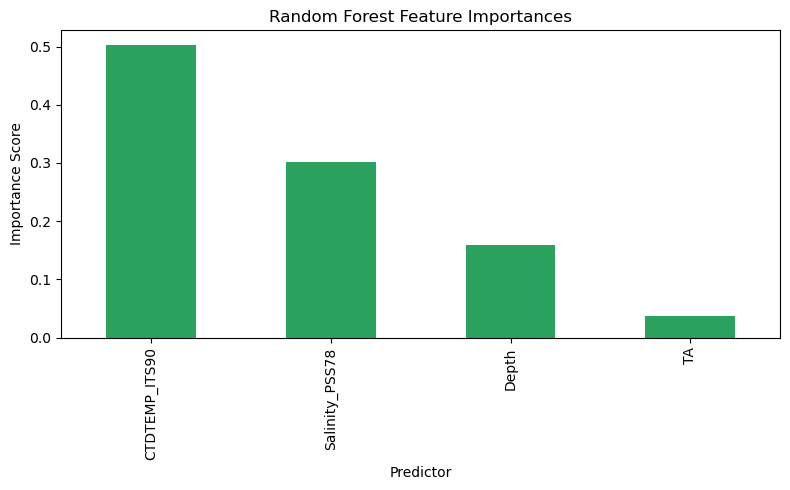

In [ ]:
# Feature importance from the tuned random forest
importances = pd.Series(best_rf.feature_importances_, index=predictors).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="bar", color="#2CA25F")
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Predictor")
plt.tight_layout()
plt.show()

## Summary

This section compares model performance side by side. The best model is selected using validation MSE/RMSE, with lower values indicating better predictive performance. The final Kaggle submission is created from the selected model after refitting it on all available training data.

In [ ]:
results_df = pd.DataFrame(model_results).sort_values("validation_mse")
results_df

,model,validation_mse,validation_rmse,validation_r2
5,Random Forest Tuned,151.731301,12.317926,0.989000
4,Random Forest Tuned,153.840258,12.403236,0.988847
3,Random Forest Baseline,159.236921,12.618911,0.988455
0,Multiple Linear Regression,1444.103966,38.001368,0.895303
1,Multiple Linear Regression,1444.103966,38.001368,0.895303
2,Ridge Regression,1444.104151,38.001370,0.895303


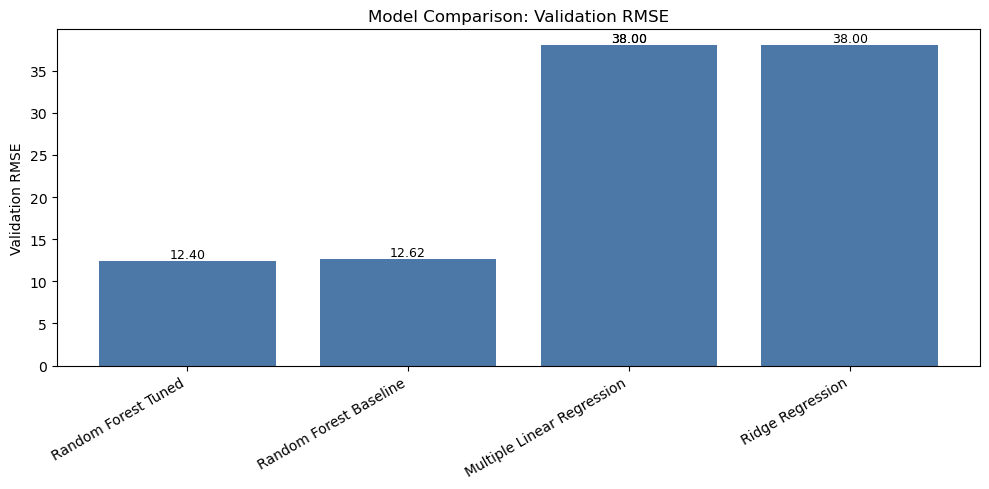

In [ ]:
# Plot validation RMSE for model comparison
plot_df = results_df.sort_values("validation_rmse", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df["model"], plot_df["validation_rmse"], color="#4C78A8")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison: Validation RMSE")
plt.xticks(rotation=30, ha="right")

for i in range(len(bars)):
    bar = bars[i]
    rmse = plot_df["validation_rmse"].iloc[i]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rmse:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Based on validation performance, the tuned random forest is selected as the final model. The linear models are useful baselines, but the random forest is expected to perform better because the relationship between DIC and the oceanographic predictors is likely nonlinear. Random forests can capture threshold effects and interactions among temperature, salinity, depth, and total alkalinity without requiring manually created polynomial or interaction terms.

The feature importance results from the tuned random forest also help interpret the model. In this validation workflow, temperature, salinity, and depth were the strongest predictors. TA had lower random forest importance, though this should not be interpreted as meaning TA is scientifically irrelevant since tree-based importance can be affected by correlation among predictors.

## Final Kaggle Submission

The selected random forest model is refit using all rows in `train.csv`, then predictions are generated for every row in `test.csv`. The submission file contains exactly two columns: `id` and `DIC`.

In [ ]:
# Fit the final model for submission
final_rf = RandomForestRegressor(
    **rf_grid.best_params_,
    random_state=RANDOM_STATE
)

final_rf.fit(X, y)

# Preict on the test set
kaggle_preds = final_rf.predict(X_kaggle_test)

# Save results as a dataframe
submission = pd.DataFrame({
    "id": df_test["id"],
    "DIC": kaggle_preds
})

submission_path = "submission_random_forest.csv"
submission.to_csv(submission_path, index=False)

print(f"Saved submission to: {submission_path}")
print(submission.head())

KeyboardInterrupt: 

In [ ]:
# Predict on SCALED test set and write submission
predictions = ridge_search.predict(X_test_scaled)
submission = pd.DataFrame({"id": test["id"], "DIC": predictions})
submission.to_csv("data/submission_ridge.csv", index=False)
submission.head()

## Final Notes

The final selected model is the tuned random forest regression model because it had the strongest validation performance among the models tested. The model was then retrained on the full training dataset before generating test-set predictions, which allows the final model to learn from all available labeled observations.